# 01 — Data Audit & Exploratory Data Analysis (EDA)
## Aoranema Sentiment Analysis

Notebook ini digunakan untuk **memahami, mengecek kualitas, membersihkan, dan menyiapkan dataset sentiment analysis** sebelum masuk ke tahap modeling.

Dataset utama:

`mobile_app_reviews.csv`

Target klasifikasi:

- `positive`
- `neutral`
- `negative`

Kolom `Emotion` **tidak digunakan sebagai target** pada project Aoranema saat ini karena fokus model adalah klasifikasi sentimen.

### Output notebook

Notebook ini akan menghasilkan:

`/kaggle/working/sentiment_clean.csv`

File tersebut nantinya menjadi input untuk notebook berikutnya:

`02_baseline_tfidf_logreg.ipynb`

> **Catatan:** cleaning dibuat seminimal mungkin. Slang, tanda baca, emoji, dan gaya bahasa informal sebisa mungkin dipertahankan karena dapat membawa informasi sentimen dan berguna untuk IndoBERT.

## 1. Import Library

Kita menggunakan library dasar untuk pengolahan data dan visualisasi.

Notebook ini **belum melakukan training model**, jadi GPU belum diperlukan.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 150)

RANDOM_STATE = 42

print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)

Pandas : 2.3.3
NumPy  : 2.0.2


## 2. Mencari Dataset di Kaggle

Karena nama folder dataset Kaggle bisa berbeda-beda, notebook akan mencari file `mobile_app_reviews.csv` secara otomatis di dalam `/kaggle/input`.

Pastikan dataset sudah ditambahkan melalui **Add Input** pada notebook Kaggle.

In [2]:
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

# Cari semua file CSV di seluruh input Kaggle
csv_files = list(KAGGLE_INPUT.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "Tidak ada file CSV yang ditemukan di /kaggle/input."
    )

print("File CSV yang ditemukan:")
for i, path in enumerate(csv_files, start=1):
    print(f"{i}. {path}")

# Karena dataset kita hanya berisi satu CSV, gunakan file pertama
DATA_PATH = csv_files[0]

print("\nDataset yang digunakan:")
print(DATA_PATH)

File CSV yang ditemukan:
1. /kaggle/input/datasets/onallaaldeanuva/mobile-app-reviews-csv/Multilabel Sentiment and Emotion Dataset from Indonesian Mobile Application Review.csv

Dataset yang digunakan:
/kaggle/input/datasets/onallaaldeanuva/mobile-app-reviews-csv/Multilabel Sentiment and Emotion Dataset from Indonesian Mobile Application Review.csv


## 3. Load Dataset

Versi dataset yang digunakan memiliki ekstensi `.csv`, tetapi pada sumber aslinya pemisah kolom dapat berupa **tab (`\t`)**.

Kode di bawah mencoba membaca sebagai tab terlebih dahulu. Jika hasilnya hanya satu kolom, notebook mencoba membaca sebagai CSV biasa.

In [3]:
def load_dataset(path: Path) -> pd.DataFrame:
    # Coba separator tab terlebih dahulu
    df_temp = pd.read_csv(path, sep="\t")

    # Fallback jika ternyata file adalah CSV biasa
    if df_temp.shape[1] == 1:
        df_temp = pd.read_csv(path)

    return df_temp


df_raw = load_dataset(DATA_PATH)

print("Ukuran dataset:", df_raw.shape)
print("Kolom:", df_raw.columns.tolist())

display(df_raw.head())

Ukuran dataset: (21696, 3)
Kolom: ['content', 'Sentiment', 'Emotion']


,content,Sentiment,Emotion
0,bukan menyenangkan malah bikin kesal hp saya realme c 11 malah ngeblank hitam ga masuk keloading giliran udah masuk malah loading nya berhenti m...,Negative,Anger
1,"kalo ngak niat bikin gamenya bagus hapus aja dah gamenya, masa setiap narik atau mabar diconet mulu, kalo niat bikin game update ada apa saja bu...",Negative,Anger
2,"kntl, masa ada iklan ngga bisa di skip. Padahal perjalanan kurang 1 kota lagi. Jadi males main online, udah gitu mobil yang dari lawan arah tiba...",Negative,Anger
3,"makin lama, makin gak jelas dri sblum di update game ini tiba tiba keluar sndiri tapi setelah di update 3.7 suka keluar sndiri di saat mau mai...",Negative,Anger
4,semenjak update sangat sangat buruk setiap main bareng sering disconeted padahal sinyal bagus cukup bintang satu aja untuk,Negative,Anger


## 4. Audit Struktur Dataset

Sebelum membersihkan data, kita perlu memahami:

- jumlah baris dan kolom,
- tipe data,
- nama kolom,
- contoh isi dataset.

Kolom yang kita butuhkan untuk sentiment analysis:

- `content` → teks feedback/review,
- `Sentiment` → label target.

Kolom `Emotion` boleh tetap ada pada data mentah, tetapi tidak digunakan untuk training sentiment model.

In [4]:
print("=== INFO DATASET ===")
df_raw.info()

print("\n=== JUMLAH BARIS DAN KOLOM ===")
print(f"Baris : {df_raw.shape[0]:,}")
print(f"Kolom : {df_raw.shape[1]}")

print("\n=== NAMA KOLOM ===")
for col in df_raw.columns:
    print("-", repr(col))

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21696 entries, 0 to 21695
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   content    21696 non-null  object
 1   Sentiment  21696 non-null  object
 2   Emotion    21696 non-null  object
dtypes: object(3)
memory usage: 508.6+ KB

=== JUMLAH BARIS DAN KOLOM ===
Baris : 21,696
Kolom : 3

=== NAMA KOLOM ===
- 'content'
- 'Sentiment'
- 'Emotion'


## 5. Standarisasi Nama Kolom

Nama kolom dinormalisasi terlebih dahulu agar penulisan kode berikutnya konsisten.

Target struktur:

```text
content
sentiment
emotion
```

In [5]:
df = df_raw.copy()

# Hilangkan spasi yang tidak sengaja pada nama kolom
df.columns = [str(col).strip().lower() for col in df.columns]

required_columns = {"content", "sentiment"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Kolom wajib tidak ditemukan: {missing_columns}. "
        f"Kolom yang tersedia: {df.columns.tolist()}"
    )

print("Kolom setelah distandarisasi:")
print(df.columns.tolist())

display(df.head())

Kolom setelah distandarisasi:
['content', 'sentiment', 'emotion']


,content,sentiment,emotion
0,bukan menyenangkan malah bikin kesal hp saya realme c 11 malah ngeblank hitam ga masuk keloading giliran udah masuk malah loading nya berhenti m...,Negative,Anger
1,"kalo ngak niat bikin gamenya bagus hapus aja dah gamenya, masa setiap narik atau mabar diconet mulu, kalo niat bikin game update ada apa saja bu...",Negative,Anger
2,"kntl, masa ada iklan ngga bisa di skip. Padahal perjalanan kurang 1 kota lagi. Jadi males main online, udah gitu mobil yang dari lawan arah tiba...",Negative,Anger
3,"makin lama, makin gak jelas dri sblum di update game ini tiba tiba keluar sndiri tapi setelah di update 3.7 suka keluar sndiri di saat mau mai...",Negative,Anger
4,semenjak update sangat sangat buruk setiap main bareng sering disconeted padahal sinyal bagus cukup bintang satu aja untuk,Negative,Anger


## 6. Pemeriksaan Missing Value

Data kosong perlu diperiksa khususnya pada:

- `content`
- `sentiment`

Baris tanpa teks atau tanpa label tidak dapat digunakan untuk supervised learning.

In [6]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

display(missing_summary)

,missing_count,missing_percent
content,0,0.0
sentiment,0,0.0
emotion,0,0.0


Kita juga perlu mengecek string kosong seperti `""` atau teks yang hanya berisi spasi karena tidak selalu terdeteksi sebagai `NaN`.

In [7]:
content_as_string = df["content"].fillna("").astype(str)

empty_content_count = content_as_string.str.strip().eq("").sum()

sentiment_as_string = df["sentiment"].fillna("").astype(str)
empty_sentiment_count = sentiment_as_string.str.strip().eq("").sum()

print("Content kosong   :", empty_content_count)
print("Sentiment kosong :", empty_sentiment_count)

Content kosong   : 0
Sentiment kosong : 0


## 7. Audit Label Sentiment

Dataset seharusnya memiliki tiga kelas:

- `positive`
- `neutral`
- `negative`

Namun penulisan label dapat berbeda karena:

- huruf besar/kecil,
- spasi di awal/akhir.

Karena itu label perlu dinormalisasi sebelum dianalisis.

In [8]:
print("=== LABEL SENTIMENT ASLI ===")

sentiment_raw_counts = (
    df["sentiment"]
    .fillna("<MISSING>")
    .astype(str)
    .value_counts(dropna=False)
)

display(sentiment_raw_counts.to_frame("count"))

=== LABEL SENTIMENT ASLI ===


,count
sentiment,
Negative,7644
Neutral,7452
Positive,6522
Negative,71
negative,6
Positive,1


### Normalisasi label

Contoh:

```text
"Negative "
" negative"
"NEGATIVE"
```

semuanya akan menjadi:

```text
negative
```

In [9]:
df["sentiment"] = (
    df["sentiment"]
    .astype("string")
    .str.strip()
    .str.lower()
)

valid_labels = {"positive", "neutral", "negative"}

invalid_mask = (
    df["sentiment"].notna()
    & ~df["sentiment"].isin(valid_labels)
)

print("Jumlah label tidak valid:", invalid_mask.sum())

if invalid_mask.any():
    display(
        df.loc[invalid_mask, ["content", "sentiment"]].head(20)
    )

Jumlah label tidak valid: 0


## 8. Distribusi Kelas Sentiment

Distribusi kelas perlu diperiksa untuk mengetahui apakah dataset sangat tidak seimbang.

Dataset yang terlalu tidak seimbang dapat membuat accuracy terlihat tinggi meskipun model buruk pada kelas minoritas.

In [10]:
sentiment_counts = (
    df["sentiment"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
)

sentiment_percent = (
    sentiment_counts / sentiment_counts.sum() * 100
).round(2)

class_distribution = pd.DataFrame({
    "count": sentiment_counts,
    "percent": sentiment_percent
})

display(class_distribution)

,count,percent
sentiment,,
negative,7721,35.59
neutral,7452,34.35
positive,6523,30.07


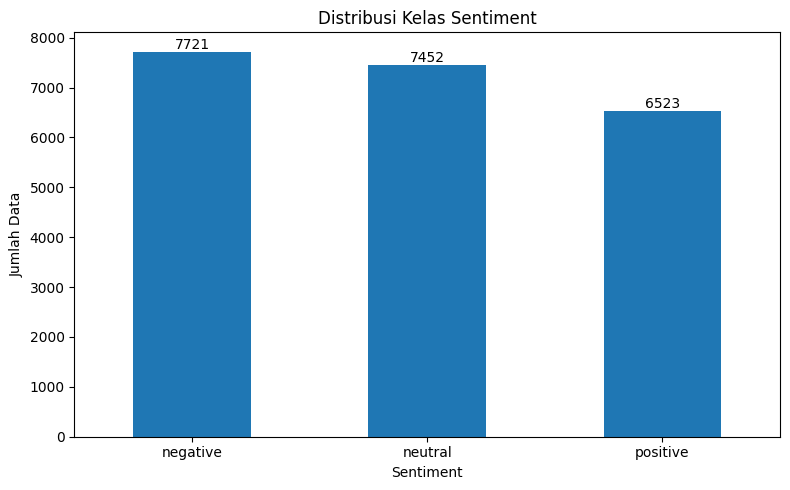

In [11]:
ax = sentiment_counts.plot(kind="bar", figsize=(8, 5))

ax.set_title("Distribusi Kelas Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Jumlah Data")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## 9. Contoh Data Tiap Sentiment

Melihat contoh aktual membantu memastikan bahwa label secara umum sesuai dengan isi teks.

Ini bukan validasi manual seluruh dataset, tetapi merupakan sanity check.

In [12]:
for label in ["positive", "neutral", "negative"]:
    print("=" * 80)
    print(f"CONTOH SENTIMENT: {label.upper()}")
    print("=" * 80)

    sample = (
        df.loc[df["sentiment"] == label, ["content", "sentiment"]]
        .sample(
            n=min(5, (df["sentiment"] == label).sum()),
            random_state=RANDOM_STATE
        )
    )

    display(sample)

CONTOH SENTIMENT: POSITIVE


,content,sentiment
8558,ini sangat membantu dalam pengerjaan tugas dan pengembangan kosakata bahasa Indonesia saya.,positive
8603,72 TH,positive
13943,Montol,positive
5669,GAMENYA SERU BANGET!!!!!!!!!!!,positive
8287,"Tetus maju,suksed",positive


CONTOH SENTIMENT: NEUTRAL


,content,sentiment
18068,Game nya bagus bus nya pun jga menarik tapi sayang nya skarng tidaak bisa cari penumpang di luar terminal lagi trus di tambah bermain dengn tman p...,neutral
15743,Terima Kasih,neutral
10293,Bang kalo bisa mud teruk nya bisa di pariasi bang supaya lebih seru bang ya saya kadih dulu bintang 3 karena belum gitu,neutral
13894,Mode main bareng nya player nya pada keluar sendiri coba perbaiki bug nya,neutral
11359,Cobain dulu deh kalau oke.. full deh bintangnya.. kayaknya sih enak liat komenan temen2 yang lain,neutral


CONTOH SENTIMENT: NEGATIVE


,content,sentiment
21016,Tidak bisa terhubung dan ada batas waktunya juga,negative
17467,Beritanya hanya penuh opini .. tidak berimbang .,negative
17187,"Bagus ada perkembangan update, tapi masih ada bug +mobil yang nyelonong ajaa,saya lagi markir pinggir jln..di trotoar ,lah malahh mobil nya ikut b...",negative
132,APK BABI SOK SOK.AN.!! VERIV KTP 10 X GAGAL MULU.!!!! SOK SOK AN. udah JELAS TULISANNYA INFONYA BLUR .. TAIK.,negative
21381,Uang sudah di trf dari jam 10 pagi.. tiba² riwayat transaksi hilang.. status tidak tau apakah berhasil atau gagal.. kembalikan uang saya..,negative


## 10. Audit Duplicate

Duplicate perlu diperiksa agar teks yang sama tidak muncul berulang kali tanpa alasan.

Lebih penting lagi, duplicate harus dibersihkan **sebelum train/validation/test split** untuk mengurangi risiko data leakage.

In [13]:
exact_duplicate_count = df.duplicated().sum()
duplicate_content_count = df["content"].duplicated().sum()

print("Duplicate seluruh baris :", exact_duplicate_count)
print("Duplicate berdasarkan content :", duplicate_content_count)

Duplicate seluruh baris : 45
Duplicate berdasarkan content : 52


### Cek konflik label pada teks yang sama

Kasus yang perlu diperhatikan:

```text
teks yang sama → positive
teks yang sama → negative
```

Jika ada, berarti satu teks memiliki lebih dari satu label sentiment dan perlu diperiksa sebelum deduplikasi.

In [14]:
content_for_audit = (
    df["content"]
    .fillna("")
    .astype(str)
    .str.strip()
)

audit_df = df.assign(content_audit=content_for_audit)

label_per_text = (
    audit_df
    .groupby("content_audit")["sentiment"]
    .nunique(dropna=True)
)

conflicting_texts = label_per_text[label_per_text > 1].index.tolist()

print("Jumlah teks dengan konflik label:", len(conflicting_texts))

if conflicting_texts:
    conflict_examples = (
        audit_df[audit_df["content_audit"].isin(conflicting_texts)]
        [["content", "sentiment"]]
        .sort_values("content")
        .head(30)
    )
    display(conflict_examples)

Jumlah teks dengan konflik label: 10


,content,sentiment
8584,top,positive
10195,Bagus tapi kurang lengkap,neutral
17241,Bagus tapi kurang lengkap,negative
12671,Kapan update,neutral
12673,Kapan update,positive
7019,Okayy,positive
14249,Okayy,neutral
7048,Omagon,positive
14327,Omagon,neutral
7904,Semoga dapat jodoh,positive


## 11. Analisis Panjang Teks

Panjang teks penting untuk memahami karakter dataset dan nantinya membantu menentukan strategi tokenisasi.

Kita melihat:

- jumlah karakter,
- jumlah kata.

In [15]:
text_series = (
    df["content"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["char_length"] = text_series.str.len()
df["word_length"] = text_series.str.split().str.len()

display(
    df[["char_length", "word_length"]]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

,char_length,word_length
count,21696.00,21696.00
mean,92.52,14.92
std,101.41,16.24
min,1.00,1.00
50%,53.00,9.00
75%,124.00,20.00
90%,228.00,37.00
95%,313.00,50.00
99%,483.00,75.00
max,1085.00,151.00


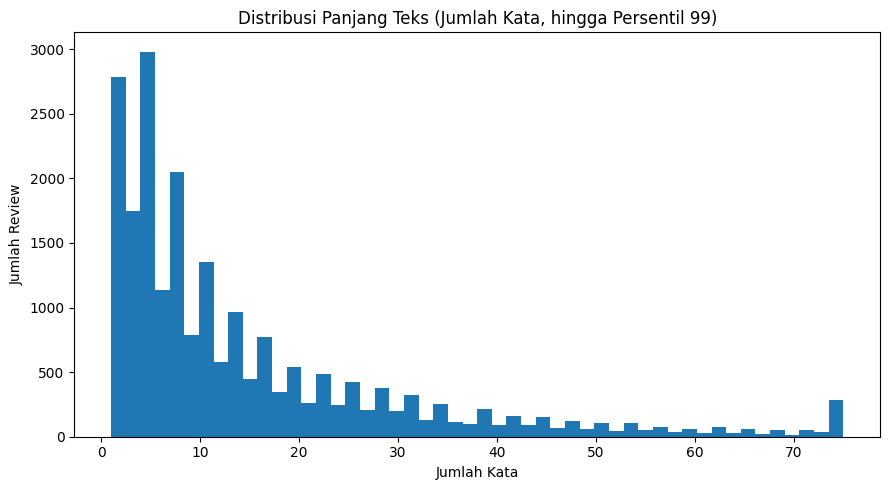

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["word_length"].clip(upper=df["word_length"].quantile(0.99)), bins=50)
ax.set_title("Distribusi Panjang Teks (Jumlah Kata, hingga Persentil 99)")
ax.set_xlabel("Jumlah Kata")
ax.set_ylabel("Jumlah Review")

plt.tight_layout()
plt.show()

## 12. Review Teks Sangat Pendek dan Sangat Panjang

Teks yang sangat pendek tidak otomatis salah.

Contoh:

```text
"bagus"
"parah"
"mantap"
```

masih dapat membawa sentimen.

Karena itu data pendek **tidak langsung dihapus**. Kita hanya mengauditnya terlebih dahulu.

In [17]:
short_reviews = df.loc[
    df["word_length"] <= 2,
    ["content", "sentiment", "word_length"]
].copy()

print("Jumlah review <= 2 kata:", len(short_reviews))
display(short_reviews.head(20))

Jumlah review <= 2 kata: 2786


,content,sentiment,word_length
5,ᗷᑌᖇIᘜ,negative,1
29,"%$>/:(&_*^%$%,*babi kau",negative,2
38,Aaaaaasu,negative,1
62,Ajg babi,negative,2
79,Alikasi goblog,negative,2
83,ampas,negative,1
84,Anak ajg,negative,2
85,ancok,negative,1
86,Ancur!!,negative,1
92,Anjay,negative,1


In [18]:
long_reviews = (
    df[["content", "sentiment", "word_length"]]
    .sort_values("word_length", ascending=False)
)

print("10 review terpanjang:")
display(long_reviews.head(10))

10 review terpanjang:


,content,sentiment,word_length
2609,"Hmm oy oy,saya mau mengkritik salah satu apk yg SEMPAT viral ini.namun hanya sesaat ini.inget sesaat ya.wkwk,why oy?kenapa harus di hapus option r...",negative,151
2997,Memang Oy adalah aplikasi Terpopuler di Indonesia..banyak yang suka apk ini semuanya pada Bagi-bagi apk ini satu sama lain..menyebarkan lewat sosm...,negative,145
14068,Nfino nn Todd HPP off KKP Kyodo JCC happy di JCC off on hall Foodism Wonderland IPCC diduga doff to lyrics Todd risih disaat di PHP yg di yg di di...,neutral,125
18588,"jadi gini. admin oy yang ganteng/cantik to the point aja, aplikasi oy ini bagus buat cari pulsa gratis karena cuma chating doang bisa dpt pulsa,vo...",negative,122
21192,Tolong dong min di benahi . bukannya makin kesini makin bagus ini oy malah jadi makin parah. Poin yang di dapat dari chat ke teman udh dikit . ini...,negative,120
9170,"Easter egg (bug) nya banyak nih haha, ini hasil kurang kerjaan saya. Kebanyakan langsung force close kalau buka pilihan dibawah ini, ada juga yang...",neutral,113
20145,"Sangat membantu. Namun amat disayangkan masih terdapat eror. Hal ini baru saya alami kemarin, ketika itu saya sedang membuka aplikasi KBBI dan m...",negative,110
18479,"Harus hp seperti apa ya , ko susah banget mau main , udh masuk pas milih tarikan , terus udh selsai mau mulai narik , dan rute , tiba tiba kluar s...",negative,109
19527,Masih banyak makna kata yang menyimpang dan ambigu. Arti imbuhan tidak dikembalikan ke bentuk dasar kata tersebut dan arti bentuk baru menjadi mel...,negative,102
2912,Kok gue gak bisa masuk ke gem nya gua kan masuk kok ada pilih file langsung gua pilih file download gak bisa gua lagi coba semua file gak bisa Gim...,negative,101


## 13. Cleaning Dataset

Cleaning dilakukan secara **minimal**.

Yang dilakukan:

1. buang baris dengan `content` kosong,
2. buang baris dengan `sentiment` kosong,
3. pertahankan hanya tiga label valid,
4. hilangkan whitespace berlebih,
5. hapus duplicate teks setelah normalisasi whitespace.

Yang **tidak** dilakukan:

- menghapus stopword,
- stemming,
- menghapus emoji,
- menghapus tanda baca,
- mengubah slang menjadi bahasa baku,
- lowercasing seluruh teks.

Alasannya: informasi tersebut bisa berguna untuk model transformer seperti IndoBERT dan kita ingin menjaga data sedekat mungkin dengan bahasa user asli.

In [19]:
df_clean = df[["content", "sentiment"]].copy()

# Buang missing value
df_clean = df_clean.dropna(subset=["content", "sentiment"])

# Pastikan string
df_clean["content"] = df_clean["content"].astype(str)
df_clean["sentiment"] = df_clean["sentiment"].astype(str)

# Hilangkan spasi awal/akhir dan gabungkan whitespace berulang
df_clean["content"] = (
    df_clean["content"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df_clean["sentiment"] = (
    df_clean["sentiment"]
    .str.strip()
    .str.lower()
)

# Buang teks kosong
df_clean = df_clean[df_clean["content"].ne("")]

# Pertahankan hanya label yang valid
df_clean = df_clean[df_clean["sentiment"].isin(valid_labels)]

before_dedup = len(df_clean)

# Hapus duplicate berdasarkan pasangan content + sentiment terlebih dahulu
df_clean = df_clean.drop_duplicates(
    subset=["content", "sentiment"],
    keep="first"
)

after_pair_dedup = len(df_clean)

print("Sebelum deduplikasi :", f"{before_dedup:,}")
print("Sesudah deduplikasi :", f"{after_pair_dedup:,}")
print("Dihapus              :", f"{before_dedup - after_pair_dedup:,}")

Sebelum deduplikasi : 21,696
Sesudah deduplikasi : 21,609
Dihapus              : 87


### Penanganan teks yang memiliki label konflik

Jika teks yang persis sama masih memiliki lebih dari satu label setelah deduplikasi pasangan `content + sentiment`, data tersebut bersifat ambigu.

Untuk dataset training yang bersih, teks konflik akan **dihapus seluruh versinya** agar model tidak menerima target yang saling bertentangan.

In [20]:
label_conflict_after_clean = (
    df_clean
    .groupby("content")["sentiment"]
    .nunique()
)

conflict_contents = label_conflict_after_clean[
    label_conflict_after_clean > 1
].index

conflict_row_count = df_clean["content"].isin(conflict_contents).sum()

print("Jumlah teks konflik :", len(conflict_contents))
print("Jumlah baris konflik:", conflict_row_count)

if len(conflict_contents) > 0:
    df_clean = df_clean[
        ~df_clean["content"].isin(conflict_contents)
    ].copy()

df_clean = df_clean.reset_index(drop=True)

print("\nUkuran dataset bersih:", df_clean.shape)

Jumlah teks konflik : 10
Jumlah baris konflik: 20

Ukuran dataset bersih: (21589, 2)


## 14. Validasi Dataset Setelah Cleaning

Kita memastikan bahwa:

- tidak ada missing value,
- tidak ada teks kosong,
- label hanya `positive`, `neutral`, `negative`,
- tidak ada duplicate pasangan teks + label.

In [21]:
print("=== VALIDASI DATA BERSIH ===")

print("Shape:", df_clean.shape)
print("Missing value:", df_clean.isna().sum().to_dict())
print("Teks kosong:", df_clean["content"].str.strip().eq("").sum())
print("Duplicate:", df_clean.duplicated(subset=["content", "sentiment"]).sum())
print("Label:", sorted(df_clean["sentiment"].unique().tolist()))

assert df_clean["content"].notna().all()
assert df_clean["sentiment"].notna().all()
assert not df_clean["content"].str.strip().eq("").any()
assert set(df_clean["sentiment"].unique()).issubset(valid_labels)
assert df_clean.duplicated(subset=["content", "sentiment"]).sum() == 0

print("\nSemua validasi lolos.")

=== VALIDASI DATA BERSIH ===
Shape: (21589, 2)
Missing value: {'content': 0, 'sentiment': 0}
Teks kosong: 0
Duplicate: 0
Label: ['negative', 'neutral', 'positive']

Semua validasi lolos.


## 15. Distribusi Sentiment Setelah Cleaning

In [22]:
final_counts = (
    df_clean["sentiment"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
)

final_percent = (
    final_counts / final_counts.sum() * 100
).round(2)

final_distribution = pd.DataFrame({
    "count": final_counts,
    "percent": final_percent
})

display(final_distribution)

,count,percent
sentiment,,
negative,7716,35.74
neutral,7423,34.38
positive,6450,29.88


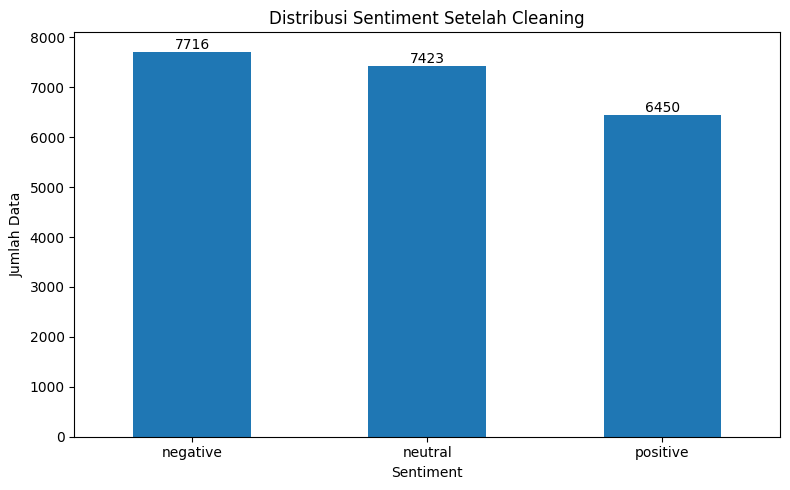

In [23]:
ax = final_counts.plot(kind="bar", figsize=(8, 5))

ax.set_title("Distribusi Sentiment Setelah Cleaning")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Jumlah Data")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## 16. Ringkasan Perubahan Dataset

Bagian ini mencatat jumlah data sebelum dan sesudah cleaning agar proses preprocessing dapat direproduksi dan dijelaskan pada dokumentasi project.

In [24]:
summary = {
    "raw_rows": int(len(df_raw)),
    "clean_rows": int(len(df_clean)),
    "removed_rows_total": int(len(df_raw) - len(df_clean)),
    "class_distribution": {
        label: int(count)
        for label, count in final_counts.dropna().items()
    }
}

display(pd.DataFrame({
    "Metric": [
        "Raw rows",
        "Clean rows",
        "Removed rows"
    ],
    "Value": [
        summary["raw_rows"],
        summary["clean_rows"],
        summary["removed_rows_total"]
    ]
}))

print("\nDistribusi kelas akhir:")
display(final_distribution)

,Metric,Value
0,Raw rows,21696
1,Clean rows,21589
2,Removed rows,107



Distribusi kelas akhir:


,count,percent
sentiment,,
negative,7716,35.74
neutral,7423,34.38
positive,6450,29.88


## 17. Simpan Dataset Bersih

Kaggle hanya mengizinkan output ditulis ke `/kaggle/working`.

Output utama:

`/kaggle/working/sentiment_clean.csv`

File ini nantinya digunakan pada:

`02_baseline_tfidf_logreg.ipynb`

In [25]:
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_DATA_PATH = OUTPUT_DIR / "sentiment_clean.csv"
SUMMARY_PATH = OUTPUT_DIR / "data_audit_summary.json"

df_clean.to_csv(
    CLEAN_DATA_PATH,
    index=False,
    encoding="utf-8"
)

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Dataset bersih tersimpan di:")
print(CLEAN_DATA_PATH)

print("\nRingkasan audit tersimpan di:")
print(SUMMARY_PATH)

Dataset bersih tersimpan di:
/kaggle/working/sentiment_clean.csv

Ringkasan audit tersimpan di:
/kaggle/working/data_audit_summary.json


## 18. Pemeriksaan Output

Kita membaca kembali file hasil cleaning untuk memastikan file berhasil disimpan dengan benar.

In [26]:
check_df = pd.read_csv(CLEAN_DATA_PATH)

print("Shape output:", check_df.shape)
print("Kolom:", check_df.columns.tolist())

display(check_df.head())

assert check_df.shape == df_clean.shape
assert check_df.columns.tolist() == ["content", "sentiment"]

print("\nOutput berhasil diverifikasi.")

Shape output: (21589, 2)
Kolom: ['content', 'sentiment']


,content,sentiment
0,bukan menyenangkan malah bikin kesal hp saya realme c 11 malah ngeblank hitam ga masuk keloading giliran udah masuk malah loading nya berhenti mas...,negative
1,"kalo ngak niat bikin gamenya bagus hapus aja dah gamenya, masa setiap narik atau mabar diconet mulu, kalo niat bikin game update ada apa saja bug ...",negative
2,"kntl, masa ada iklan ngga bisa di skip. Padahal perjalanan kurang 1 kota lagi. Jadi males main online, udah gitu mobil yang dari lawan arah tiba"" ...",negative
3,"makin lama, makin gak jelas dri sblum di update game ini tiba tiba keluar sndiri tapi setelah di update 3.7 suka keluar sndiri di saat mau main, m...",negative
4,semenjak update sangat sangat buruk setiap main bareng sering disconeted padahal sinyal bagus cukup bintang satu aja untuk,negative



Output berhasil diverifikasi.


# Kesimpulan Notebook 01

Pada notebook ini kita sudah:

- memuat dataset dari Kaggle,
- memeriksa struktur dataset,
- mengecek missing value,
- menormalisasi label sentiment,
- menganalisis distribusi kelas,
- memeriksa duplicate dan konflik label,
- menganalisis panjang teks,
- melakukan cleaning minimal,
- memvalidasi dataset bersih,
- menyimpan `sentiment_clean.csv`.

## Dataset untuk tahap berikutnya

```text
/kaggle/working/sentiment_clean.csv
```

Tahap berikutnya:

**02 — Baseline TF-IDF + Logistic Regression**

Di notebook tersebut kita akan membuat train/validation/test split secara stratified, membangun baseline model, lalu mengevaluasi Accuracy, Precision, Recall, Macro F1, dan Confusion Matrix.